# 1. 📚 Importar librerias

In [30]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [31]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew
from src.preprocessing import clean_data
from src.outliers import clean_outliers
from src.pipeline import run_pipeline

# 2. 📊 Cargar csv/df

In [32]:
'''
        En esta ocasion no es necesario aplicar un df.copy(), ya que la informacion viene de la lista y DF no 
        es una vista de la informacion, es un objeto nuevo.
'''
small_data = '../data/raw/2023-03-08 Precios Casas RM.csv'
large_data = '../data/raw/2023-07-18 Propiedades Web Scrape.csv' 

DTYPES = {
    'Price_UF': 'float32',
    'Built Area': 'float32',
    'Total Area': 'float32',
    'Baths': 'Int8',
    'Dorms': 'Int8',
    'Parking': 'Int8',
}

# Importamos el archivo csv a la variable df
lst = list() # Cremos una lista para guardar los chunks

for chunk in pd.read_csv(large_data, chunksize = 1000, dtype=DTYPES):
   lst.append(chunk) # Guardamos los chunks de datos en la lista

df = pd.concat(lst) # Optimizamos memoria y concatenamos toda la informacion fuera de loop en un mismo DF

#               ^^^^^^^^^^^^^^^^^^             -------------->                **************
# df = pd.concat(pd.read_csv(large_data, chunksize=1000, dtype=DTYPES)) # Equivalente implicito

display(df)

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
0,129884400,3600.0,158396.0,Lampa,AvenidaLaHacienda,3,2,68.0,221.0,1,7850612,Behouse
1,130000000,3603.0,158537.0,Buin,Villaseca,5,3,150.0,190.0,2,10081485,NaN
2,172998805,4795.0,210974.0,PuenteAlto,BarrioAustria,4,3,90.0,182.0,3,10257247,Bissac
3,135296250,3750.0,164995.0,Buin,ComercianteArmandoPérezCarrasco,3,2,85.0,175.0,1,20153043,Ambiento Propiedades
4,195000000,5405.0,237805.0,QuintaNormal,Hostos,3,3,130.0,402.0,1,16669338,Puntoinmobiliario.cl
...,...,...,...,...,...,...,...,...,...,...,...,...
9286,80000000,2217.0,97561.0,PuenteAlto,LasAvestruces0352,2,1,75.0,100.0,2,7817190,Margarita Leiva Catalan
9287,250000000,6929.0,304878.0,PuenteAlto,manuelrodriguez,4,2,196.0,750.0,<NA>,7650477,Margarita Leiva Catalan
9288,3788295000,105000.0,4619872.0,LasCondes,CaminoLasFlores/CaminoPiedraRoja,5,7,460.0,4925.0,8,6032811,Tsi Property
9289,577264000,16000.0,703980.0,LaPintana,LosCipreses/LosDuraznos,4,2,311.0,2011.0,1,5314376,Tsi Property


# 3. 🔬 EDA
Comenzamos un EDA

In [33]:
display(df.info(),df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9291 entries, 0 to 9290
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price_CLP   9291 non-null   int64  
 1   Price_UF    9291 non-null   float32
 2   Price_USD   9291 non-null   float64
 3   Comuna      9291 non-null   object 
 4   Ubicacion   9291 non-null   object 
 5   Dorms       9202 non-null   Int8   
 6   Baths       9138 non-null   Int8   
 7   Built Area  9013 non-null   float32
 8   Total Area  9057 non-null   float32
 9   Parking     6371 non-null   Int8   
 10  id          9291 non-null   int64  
 11  Realtor     8125 non-null   object 
dtypes: Int8(3), float32(3), float64(1), int64(2), object(3)
memory usage: 599.0+ KB


None

(9291, 12)

El dataset contiene 9291 entradas, sin embargo hay variables que contienen menos datos, lo que nos indica que hay valores nulos

In [34]:
df.isnull().sum()

Price_CLP        0
Price_UF         0
Price_USD        0
Comuna           0
Ubicacion        0
Dorms           89
Baths          153
Built Area     278
Total Area     234
Parking       2920
id               0
Realtor       1166
dtype: int64

In [35]:
cols = ['Baths', 'Built Area', 'Total Area', 'Parking', 'Realtor', 'Dorms']
for col in cols:
    print(f'% de datos que son nulos para "{col}": { ( ( df[col].isnull().sum() / df.shape[0] ) * 100 ).round(2) }%')

% de datos que son nulos para "Baths": 1.65%
% de datos que son nulos para "Built Area": 2.99%
% de datos que son nulos para "Total Area": 2.52%
% de datos que son nulos para "Parking": 31.43%
% de datos que son nulos para "Realtor": 12.55%
% de datos que son nulos para "Dorms": 0.96%


In [36]:
df.columns

Index(['Price_CLP', 'Price_UF', 'Price_USD', 'Comuna', 'Ubicacion', 'Dorms',
       'Baths', 'Built Area', 'Total Area', 'Parking', 'id', 'Realtor'],
      dtype='object')

In [37]:
df.describe().style.format('{:,.2f}')

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
count,"9,291.00","9,291.00","9,291.00","9,202.00","9,138.00","9,013.00","9,057.00","6,371.00","9,291.00"
mean,"392,513,379.71","10,879.28","478,674.86",4.03,2.75,"6,091.60",890.98,2.68,"14,111,574.63"
std,"403,651,502.95","11,187.99","492,257.92",1.66,1.48,"527,436.69","11,291.40",2.22,"4,187,239.01"
min,"37,000,000.00","1,026.00","45,122.00",1.00,1.00,1.00,1.00,1.00,"1,213,620.00"
25%,"128,206,726.50","3,553.50","156,350.00",3.00,2.00,90.00,134.00,1.00,"11,087,459.00"
50%,"234,513,500.00","6,500.00","285,992.00",4.00,3.00,131.00,230.00,2.00,"14,436,826.00"
75%,"526,753,400.00","14,600.00","642,382.00",5.00,3.00,209.00,480.00,3.00,"17,844,280.00"
max,"4,870,665,000.00","135,000.00","5,939,835.00",35.00,29.00,"50,000,000.00","720,000.00",26.00,"20,161,463.00"


# 4. ☣️ Limpieza datos 

In [38]:
df[df.duplicated()]

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor


In [39]:
df_clean = clean_data(df)

In [40]:
display(df_clean[df_clean.duplicated()])

,Price_UF,Comuna,Dorms,Baths,Built Area,Total Area,Parking,Realtor


np.float32(0.23733996)

np.float32(2.5127544)

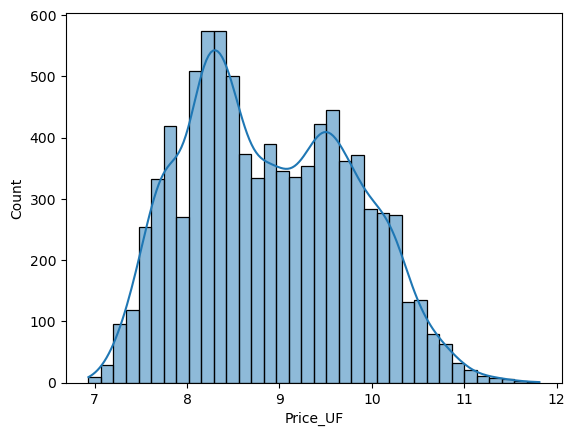

In [41]:
sns.histplot(np.log(df_clean['Price_UF']), kde=True)

display(np.log(df_clean['Price_UF']).skew(),df_clean['Price_UF'].skew())

## 4.1 🐕 Eliminacion de outliers

/usr/lib/python3.14/site-packages/pandas/core/arrays/masked.py:691: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs2, **kwargs)


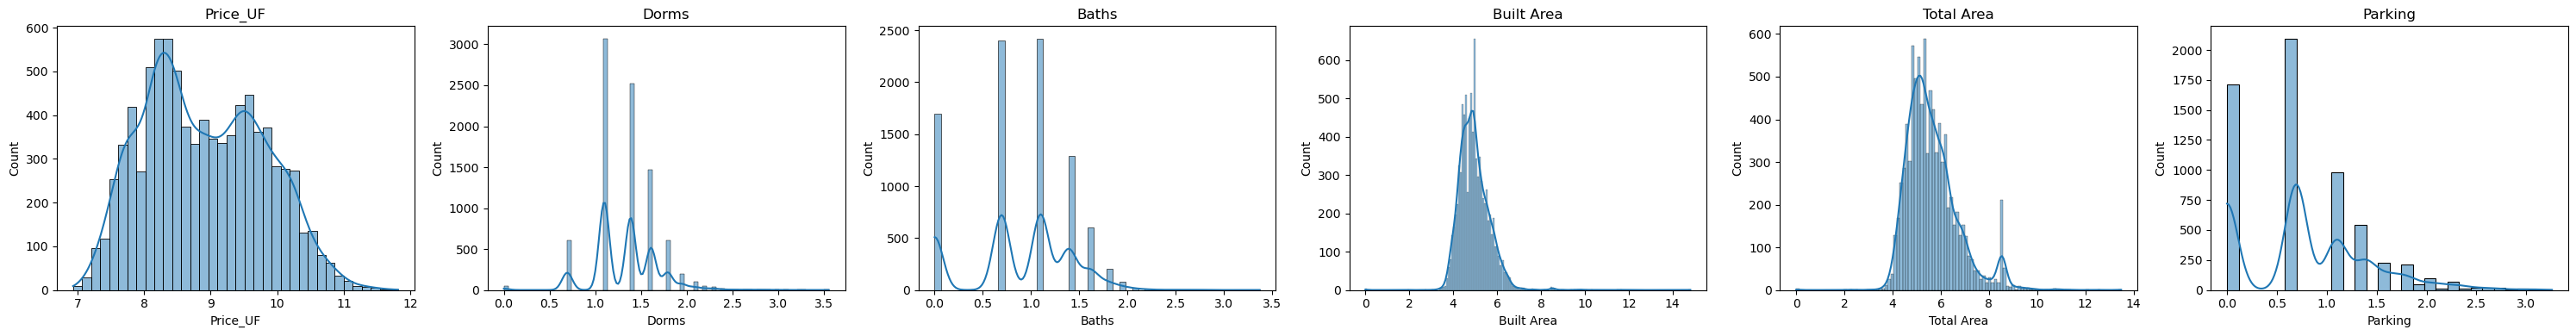

In [42]:
cols = df_clean.select_dtypes(include='number').columns

fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols),4))
for i, col in enumerate(cols):
    sns.histplot(np.log(df_clean[col]), kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [43]:
df_clean = clean_outliers(df_clean)

In [44]:
df_clean['UF_m2'] = (df_clean['Price_UF'] / df_clean['Built Area']).round(2)

# 5. 🕶️ Analisis

Text(0, 0.5, 'Casas')

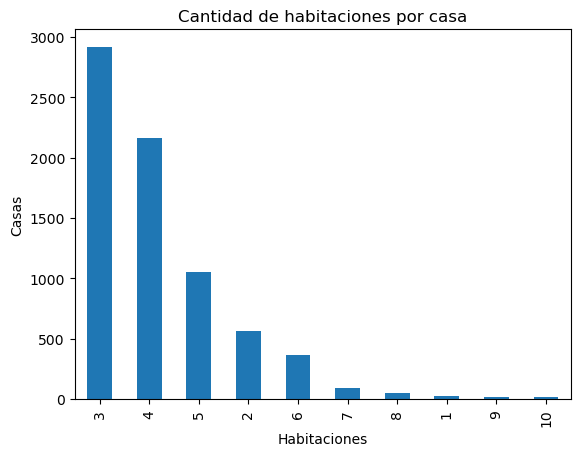

In [45]:
#plt.style.use('ggplot') #fivethirtyeight
ax = df_clean['Dorms'].value_counts().head(10)\
    .plot(kind='bar', 
          title='Cantidad de habitaciones por casa')
ax.set_xlabel('Habitaciones')
ax.set_ylabel('Casas')

Text(0, 0.5, 'Comuna')

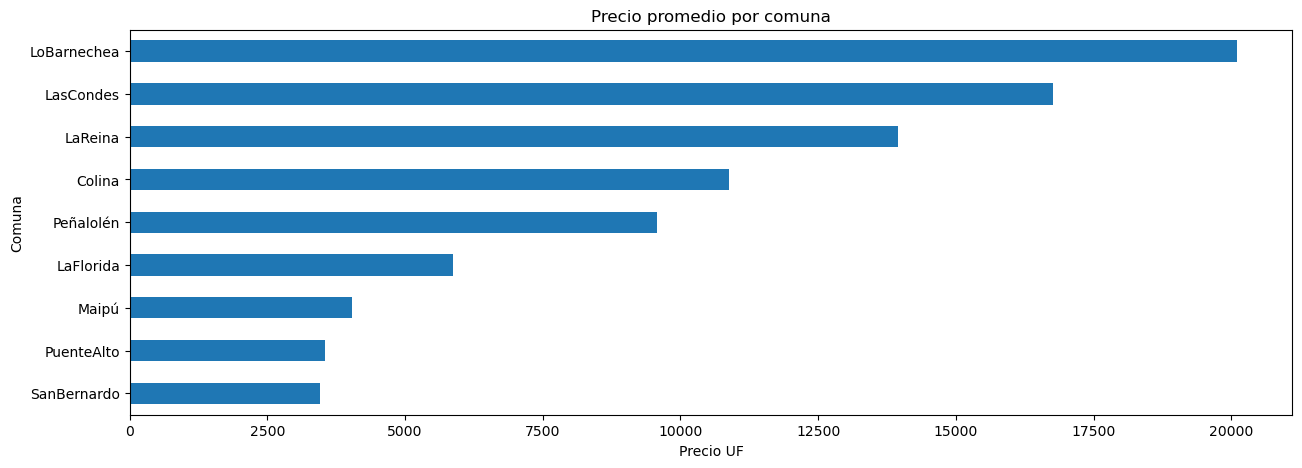

In [46]:
bx = df_clean.groupby('Comuna')['Price_UF'] \
    .agg(['mean', 'count']) \
    .query('count >= 250') \
    .sort_values('mean')['mean'] \
    .plot(kind='barh',
          figsize=(15,5),
          title='Precio promedio por comuna')
bx.set_xlabel('Precio UF')
bx.set_ylabel('Comuna')

Text(0, 0.5, 'Comuna')

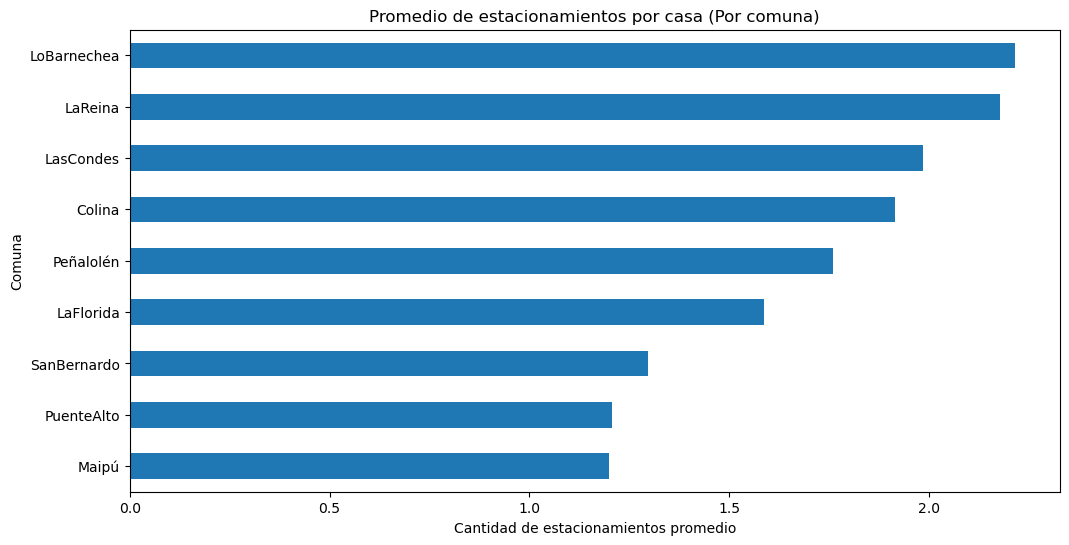

In [47]:
cx = (
    df_clean
    .groupby('Comuna')['Parking'] # Agrupa por comuna y selecciona solo la columna Parking para los valores
    .agg(['mean', 'count'])
    .query('count >= 250')
    .sort_values('mean')['mean'] # Ordena y se queda solo con 'mean' para graficar
    .plot(
        kind='barh',
        figsize=(12,6),
        title='Promedio de estacionamientos por casa (Por comuna)'
    )
)

cx.set_xlabel('Cantidad de estacionamientos promedio')
cx.set_ylabel('Comuna')

Text(0, 0.5, 'Comuna')

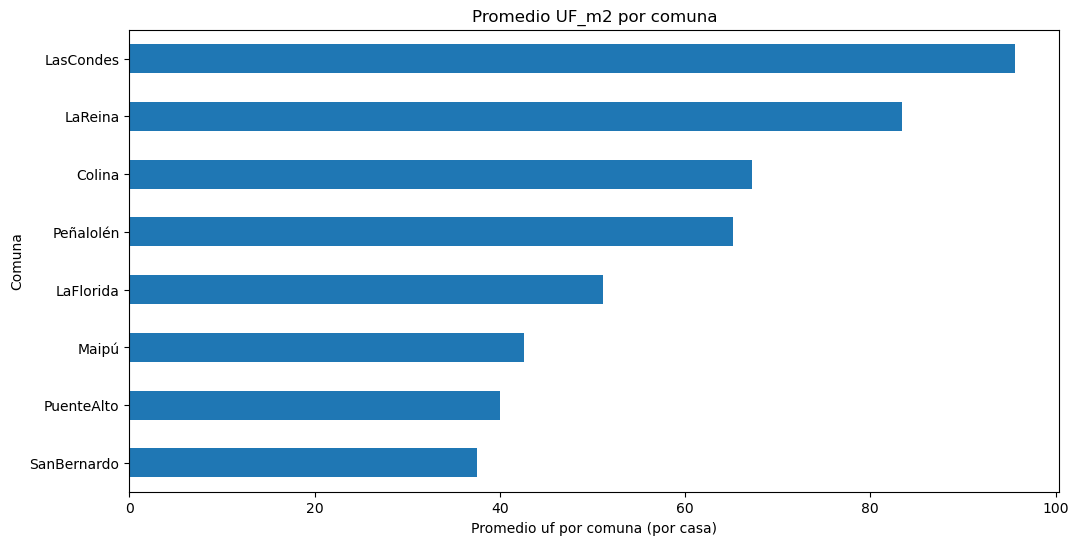

In [48]:
df_clean['UF_m2'] = (df_clean['Price_UF'] / df_clean['Built Area'])

dx = df_clean.groupby('Comuna')['UF_m2'] \
    .agg(['mean','count']) \
    .query('count > 250') \
    .sort_values('mean')['mean'] \
    .plot(
        kind='barh',
        figsize=(12,6),
        title='Promedio UF_m2 por comuna'
    )

dx.set_xlabel('Promedio uf por comuna (por casa)')
dx.set_ylabel('Comuna')

In [49]:
#corr = df_clean.drop(columns=['Comuna','id','Ubicacion','Realtor','Price_CLP','Price_USD']).corr()
corr = df_clean.select_dtypes('number').corr()
display(corr)

,Price_UF,Dorms,Baths,Built Area,Total Area,Parking,UF_m2
Price_UF,1.000000,0.371350,0.655441,0.749775,0.771747,0.298644,0.781301
Dorms,0.371350,1.000000,0.472032,0.538667,0.350454,0.122109,0.101009
Baths,0.655441,0.472032,1.000000,0.624009,0.528309,0.243721,0.430164
Built Area,0.749775,0.538667,0.624009,1.000000,0.700553,0.252027,0.256497
Total Area,0.771747,0.350454,0.528309,0.700553,1.000000,0.332632,0.518233
Parking,0.298644,0.122109,0.243721,0.252027,0.332632,1.000000,0.233186
UF_m2,0.781301,0.101009,0.430164,0.256497,0.518233,0.233186,1.000000


<Axes: >

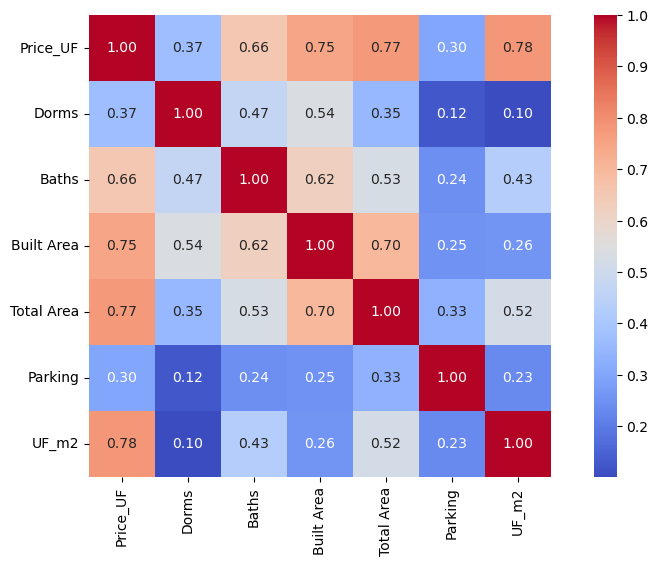

In [50]:
plt.figure(figsize=(11,6))
sns.heatmap(corr,
            cmap='coolwarm',
            square=True,
            fmt='.2f',
            annot=True)

In [51]:
df_clean['log_price'] = np.log(df_clean['Price_UF'])
df_clean['log_area'] = np.log(df_clean['Total Area'])
display(df_clean[['Price_UF','Total Area']].corr())
display(df_clean[['log_price','Total Area']].corr())
display(df_clean[['log_price','log_area']].corr())

,Price_UF,Total Area
Price_UF,1.000000,0.771747
Total Area,0.771747,1.000000


,log_price,Total Area
log_price,1.000000,0.750838
Total Area,0.750838,1.000000


,log_price,log_area
log_price,1.000000,0.811344
log_area,0.811344,1.000000


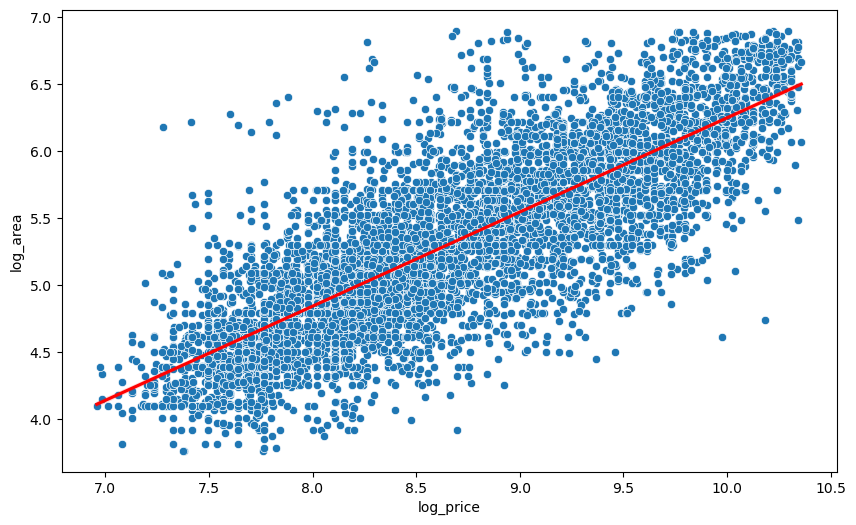

In [52]:
# Crear grafico de dispersion
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='log_price', y='log_area')

# Agregar linea de regresion
sns.regplot(data=df_clean, x='log_price', y='log_area', scatter=False, color='red')

plt.show()

In [53]:
df_clean.to_csv('../data/processed/casas_chile_limpio.csv', index=False)

In [54]:
resumen = (
    df_clean
    .groupby(['Comuna', 'Dorms'])
    .agg(
        precio_promedio=('Price_UF', 'mean'),
        precio_mediano=('Price_UF', 'median'),
        superficie_prom=('Built Area', 'mean'),
        uf_m2_prom=('UF_m2', 'mean'),
        cantidad=('Price_UF', 'count'),
    )
    .query('cantidad >= 30')           
    .sort_values(['Comuna', 'precio_promedio'], ascending=[True, False])
    .round(2)
)

umbral = 0.2
promedio_global = df_clean.groupby('Comuna')['UF_m2'].transform('mean') * umbral

df_clean['es_barata'] = (df_clean['UF_m2'] < promedio_global)

baratas = (
    df_clean
    .groupby(['Comuna'])
    .agg(
        promedio_comuna=('Price_UF', 'mean'),
        uf_m2_prom=('UF_m2','mean'),
        cantidad =('Price_UF', 'count'),
        casas_baratas=('es_barata', 'sum'),
        umbral = ('UF_m2', lambda x: x.mean() * umbral)
    )
    .query('cantidad >= 30')
    .sort_values('uf_m2_prom', ascending=False)
)

display(resumen)
display(df_clean[df_clean['UF_m2'] < promedio_global])
display(baratas)
#df_clean.drop(columns=['es_barata'], inplace=True)

precio_promedio  precio_mediano  superficie_prom  \
Comuna          Dorms                                                     
Buin            3          4747.419922          4275.5        92.650002   
Cerrillos       3          4049.270020          4158.0       110.910004   
Colina          5         14788.549805         14290.0       214.259995   
                4         12165.530273         12650.0       173.770004   
                3          9385.490234          9745.0       132.639999   
ElBosque        3          3317.800049          3042.0       102.349998   
EstaciónCentral 3          4408.439941          3850.0       112.760002   
Huechuraba      4          8008.350098          7475.0       145.039993   
                3          6529.160156          6045.0       111.339996   
LaFlorida       5          7533.379883          7251.5       150.000000   
                4          6775.100098          6500.0       127.519997   
                3          5200.240234          4581.5       103.320000   
LaReina         5         15679.429688         14600.0       192.839996   
                4         14386.839844         12995.0       169.100006   
                3         11088.450195         10948.0       132.300003   
Lampa           4          4064.620117          3991.0       113.949997   
                3          4002.239990          3850.0        86.639999   
LasCondes       5         19593.070312         19800.0       216.440002   
                6         19266.750000         19250.0       229.360001   
                4         16427.539062         15700.0       175.940002   
                3         13454.549805         12895.0       133.160004   
LoBarnechea     6         22146.310547         21450.0       254.410004   
                5         20773.810547         19990.0       219.809998   
                4         19934.359375         19900.0       210.639999   
Macul           4          6165.310059          6098.0       123.419998   
                3          5818.419922          5233.0       107.309998   
Maipú           5          5136.310059          4435.0       128.910004   
                4          4305.189941          4019.0       112.870003   
                3          3907.169922          3742.0        87.599998   
                2          2823.260010          2633.0        73.540001   
PadreHurtado    3          3980.149902          3360.5        91.300003   
Peñaflor        3          3585.520020          3850.0        88.269997   
Peñalolén       5         10915.830078         10850.0       163.360001   
                4          8993.150391          9000.0       143.690002   
                3          8144.029785          8250.0       119.739998   
Providencia     4         15453.389648         14225.0       173.199997   
Pudahuel        4          6023.640137          6490.0       123.099998   
                3          5614.000000          5266.0       109.690002   
PuenteAlto      5          4564.490234          4300.0       129.270004   
                4          3981.010010          3849.0       101.580002   
                3          3492.199951          3437.0        86.279999   
                2          2311.979980          2090.0        68.870003   
Quilicura       4          4398.209961          4435.0       105.300003   
                3          4157.649902          4200.0        90.330002   
Renca           3          3270.510010          3400.0        84.349998   
SanBernardo     3          3631.899902          3495.0        88.949997   
                4          3469.489990          3093.0       108.160004   
                2          2349.620117          2148.0        66.099998   
SanMiguel       4          9871.650391          9025.5       159.679993   
Santiago        4          6366.359863          5425.0       141.869995   
                3          5027.020020          4352.0       115.639999   
Vitacura        5         19845.279297         1

,Price_UF,Comuna,Dorms,Baths,Built Area,Total Area,Parking,Realtor,UF_m2,log_price,log_area,es_barata
2058,1450.0,Colina,3,4,139.0,480.0,2,Mi Llave,10.431655,7.279319,6.173786,True
2651,1524.0,Colina,4,1,117.0,85.0,1,Desconocido,13.025641,7.329094,4.442651,True
3060,1926.0,Colina,5,2,168.0,108.0,1,Patricio Gajardo propiedades,11.464286,7.563200,4.682131,True
3109,2162.0,Colina,11,4,184.0,184.0,3,Agente Propiedades,11.750000,7.678789,5.214936,True
3817,1691.0,Colina,4,2,270.0,270.0,0,Urbalia,6.262963,7.433075,5.598422,True
7415,1386.0,Colina,3,1,130.0,90.0,0,Propiedades Centro Santiago SPA,10.661538,7.234177,4.499810,True


,promedio_comuna,uf_m2_prom,cantidad,casas_baratas,umbral
Comuna,,,,,
Vitacura,17984.218750,112.203377,173,0,22.440678
LasCondes,16771.900391,95.617470,686,0,19.123495
LoBarnechea,20103.535156,93.778091,250,0,18.755619
Providencia,16269.507812,86.163017,134,0,17.232603
LaReina,13948.708984,83.415131,265,0,16.683027
Ñuñoa,11411.500000,76.454521,232,0,15.290904
Colina,10877.917969,67.178055,465,6,13.435611
Peñalolén,9568.561523,65.215645,315,0,13.043128
SanMiguel,9024.616211,60.579826,99,0,12.115966


In [55]:
# Tabla 1: Resumen por comuna
resumen_comuna = (
    df_clean
    .groupby('Comuna')
    .agg(
        precio_promedio = ('Price_UF', 'mean'),
        uf_m2_promedio = ('UF_m2', 'mean'),
        total_propiedades = ('Price_UF', 'count')
    )
    .reset_index()
)

# Tabla 2: Comunas premium
premium = (
    df_clean
    .groupby('Comuna')
    .agg(
        precio_maximo=('Price_UF','max'),
        superficie_maxima=('Total Area','max'),
    )
    .reset_index()
)

# Join entre columnas
analisis_comunas = pd.merge(
    resumen_comuna,             # Left
    premium,                    # Right
    how = 'inner',              # Tipo de join, inner, outer, left, right
    on = 'Comuna',              # Sobre que columna se va a realizar
).sort_values('precio_promedio', ascending=False)

display(analisis_comunas)

,Comuna,precio_promedio,uf_m2_promedio,total_propiedades,precio_maximo,superficie_maxima
20,LoBarnechea,20103.535156,93.778091,250,31500.0,988.0
47,Vitacura,17984.218750,112.203377,173,29774.0,650.0
19,LasCondes,16771.900391,95.617470,686,30900.0,985.0
32,Providencia,16269.507812,86.163017,134,31500.0,890.0
17,LaReina,13948.708984,83.415131,265,31000.0,980.0
48,Ñuñoa,11411.500000,76.454521,232,30000.0,784.0
4,Colina,10877.917969,67.178055,465,27500.0,980.0
30,Peñalolén,9568.561523,65.215645,315,19999.0,920.0
42,SanMiguel,9024.616211,60.579826,99,22990.0,836.0
10,Huechuraba,7711.008789,58.034229,117,22000.0,805.0


In [56]:
analisis_comunas = (
    df_clean.
    groupby('Comuna')
    .agg(
        precio_promedio = ('Price_UF','mean'),
        uf_m2_promedio = ('UF_m2', 'mean'),
        total_propiedades = ('Price_UF', 'count'),
        precio_maximo = ('Price_UF', 'max'),
        superficie_maxima = ('Total Area', 'max'),
    )
    .query('total_propiedades > 30')
    .sort_values('precio_promedio', ascending = False)
    .reset_index()
)
analisis_comunas

,Comuna,precio_promedio,uf_m2_promedio,total_propiedades,precio_maximo,superficie_maxima
0,LoBarnechea,20103.535156,93.778091,250,31500.0,988.0
1,Vitacura,17984.218750,112.203377,173,29774.0,650.0
2,LasCondes,16771.900391,95.617470,686,30900.0,985.0
3,Providencia,16269.507812,86.163017,134,31500.0,890.0
4,LaReina,13948.708984,83.415131,265,31000.0,980.0
5,Ñuñoa,11411.500000,76.454521,232,30000.0,784.0
6,Colina,10877.917969,67.178055,465,27500.0,980.0
7,Peñalolén,9568.561523,65.215645,315,19999.0,920.0
8,SanMiguel,9024.616211,60.579826,99,22990.0,836.0
9,Huechuraba,7711.008789,58.034229,117,22000.0,805.0
